# Scikit-learn Pipelines & Tuned Mini-Project 

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

## Introduction

This notebook is brings together a complete machine learning workflow, starting from Exploratory Data Analysis (EDA) and feature engineering and ending with model tuning and final evaluation.

The objective of this project is to build a classification model using the `Titanic dataset` to predict whether a passenger survived. Before building the model. We will investigate which characteristics are associated with survival by exploring the dataset and its features,  understand the passengers, and examine the distribution of survival. These observations will guide our feature engineering. 
The project will then follow a complete machine learning pipeline, from data analysis and feature engineering to preprocessing, model training, tuning, and final evaluation

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Phase 1 : Exploratory Data Analysis (EDA)

## 1.1 Dataset Description

### The dataset used : [Titanic dataset from kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset)
> This dataset contains information about the passengers aboard the Titanic and aims to study the factors associated with their survival

| Feature       | Meaning                              | Type                 | 
| ------------- | ------------------------------------ | -------------------- |
| `PassengerId` | Unique ID assigned to each passenger | Numerical / ID       | 
| `Survived`    | Whether the passenger survived       | Binary target        | 
| `Pclass`      | Passenger's ticket class             | Ordinal categorical  | 
| `Name`        | Passenger's full name                | Text                 | 
| `Sex`         | Passenger's sex                      | Categorical          | 
| `Age`         | Passenger's age                      | Continuous numerical | 
| `SibSp`       | Number of siblings/spouses aboard    | Discrete numerical   | 
| `Parch`       | Number of parents/children aboard    | Discrete numerical   | 
| `Ticket`      | Ticket number                        | Categorical/text     | 
| `Fare`        | Ticket price paid                    | Continuous numerical | 
| `Cabin`       | Cabin number                         | Categorical/text     |
| `Embarked`    | Port where passenger boarded         | Categorical          |


-------

## 1.2 Loading the dataset

In [54]:
# First we upload our dataset
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")
print("Shape:", df.shape)
df.head()

X = df.drop("Survived", axis=1) # features: everything except the target
y = df["Survived"]

# Missing values per column
missing = df.isnull().sum()

print(missing)
print("Number of duplicate rows:", df.duplicated().sum())



X = df.drop("Survived", axis=1)
y = df["Survived"]



Shape: (891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Number of duplicate rows: 0


### NOTE:
>The dataset contains a significant number of missing values, particularly in the `Cabin` feature, which has more than 600 missing entries. Other features, such as `Age` and `Embarked`, also contain missing values. These missing values will  be handled during the [preprocessing stage in Section 4](#prep) to prevent data leakage.

In [2]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


-------

## 1.3 Checking Data Imbalance

Counts:
 Survived
Did Not Survived    549
Survived            342
Name: count, dtype: int64

Percentages:
 Survived
Did Not Survived    61.6
Survived            38.4
Name: proportion, dtype: float64


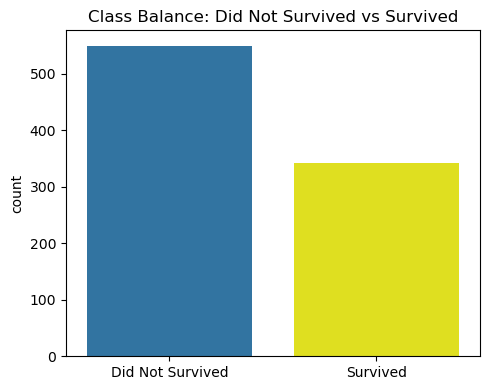

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df['Survived'].value_counts().rename({0: 'Did Not Survived', 1: 'Survived'})
class_pct = df['Survived'].value_counts(normalize=True).rename({0: 'Did Not Survived', 1: 'Survived'}).round(3) * 100

print("Counts:\n", class_counts)
print("\nPercentages:\n", class_pct)

# Define exact colors for each category 
palette = {0: 'tab:blue', 1: 'yellow'} 

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(
    data=df, 
    x='Survived', 
    hue='Survived', 
    palette=palette,  
    legend=False, 
    ax=ax
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Did Not Survived', 'Survived'])
ax.set_xlabel('')
ax.set_title('Class Balance: Did Not Survived vs Survived')
plt.tight_layout()
plt.show()

### Data Imbalance
> The target variable shows a moderate class imbalance with approximately **40% of passengers surviving** and **60% not surviving**. Although the imbalance is not severe, it considered when [evaluating the model](#eval). 

------

## 1.4 Seperate Colums By Type To analyze data distribution

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Survived').tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)

Numeric features:
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical features:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


-----

## 1.5 Correlations Between Features

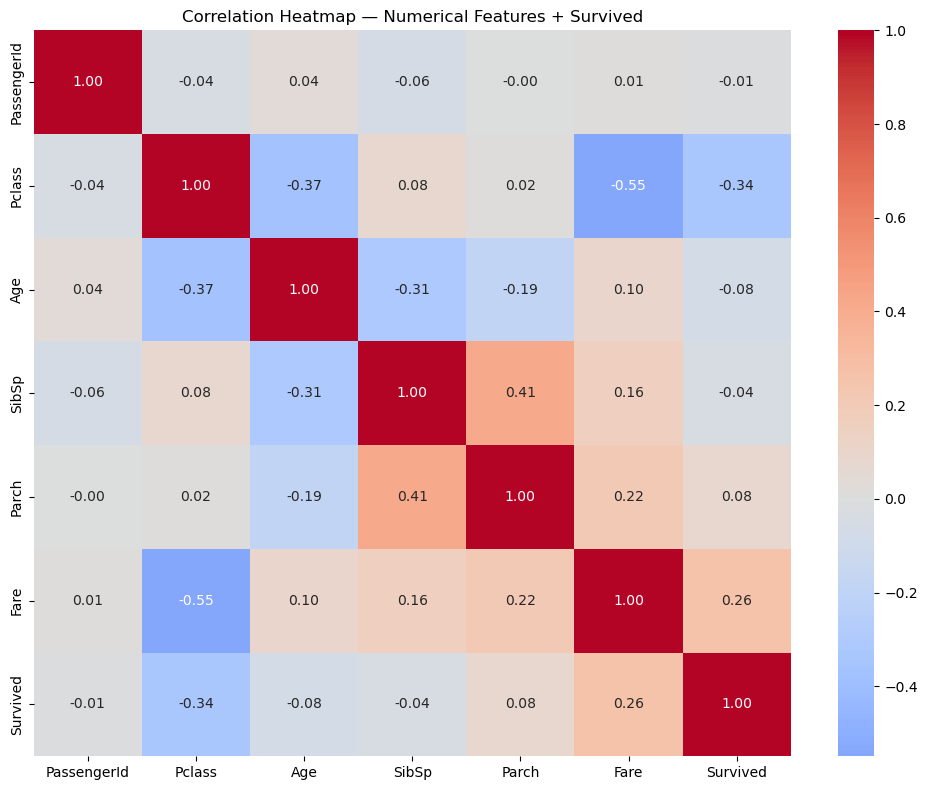

In [5]:
corr_cols = numeric_cols + ['Survived']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
ax.set_title('Correlation Heatmap — Numerical Features + Survived')
plt.tight_layout()
plt.show()

### Observations : 
`Pclass` and `Fare` show the strongest linear relationships with survival. However, the weak correlations of features such as `Age`, `SibSp`, and `Parch` do not mean they are unimportant, since they may have non-linear relationships with survival. This supports the use of [feature engineering](#eng) to capture patterns that simple correlations may not reveal.

--------

## 1.6 Detecting Outllies

In [57]:
numeric_cols = [
    'Age',
    'Fare',
    'SibSp',
    'Parch'
    
]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Age: 11 outliers
Fare: 116 outliers
SibSp: 46 outliers
Parch: 213 outliers


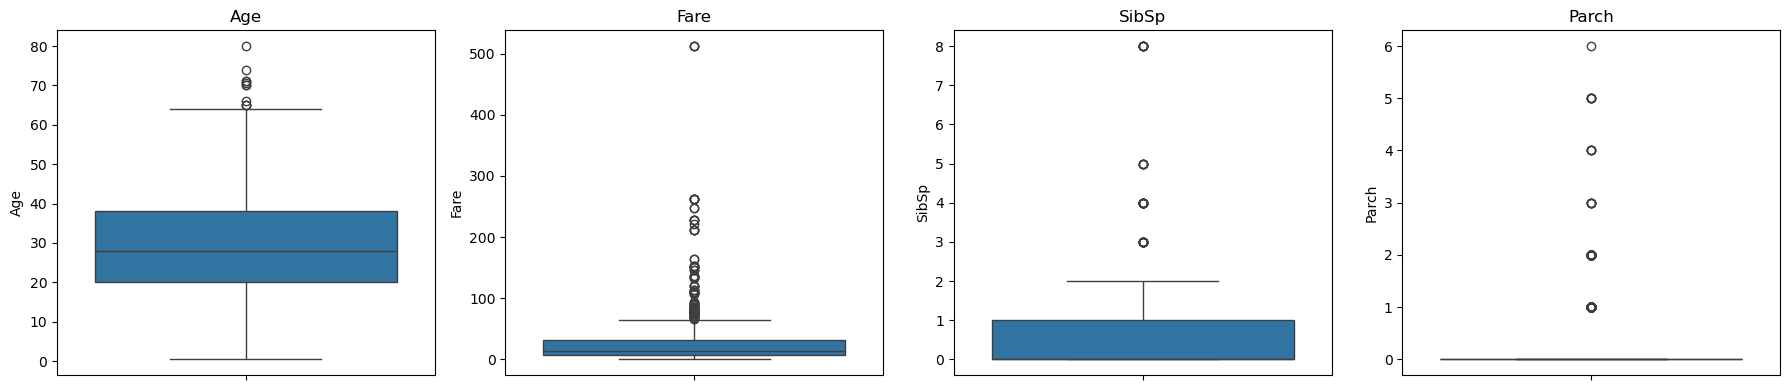

In [58]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Observation :
The detected outliers were kept because they represent valid passenger characteristics rather than obvious data-entry errors. Removing them could eliminate useful information for important features such as `Fare`, `SibSp`, and `Parch`.

-------

## 1.7 Studying Feature Distributions Using Histograms

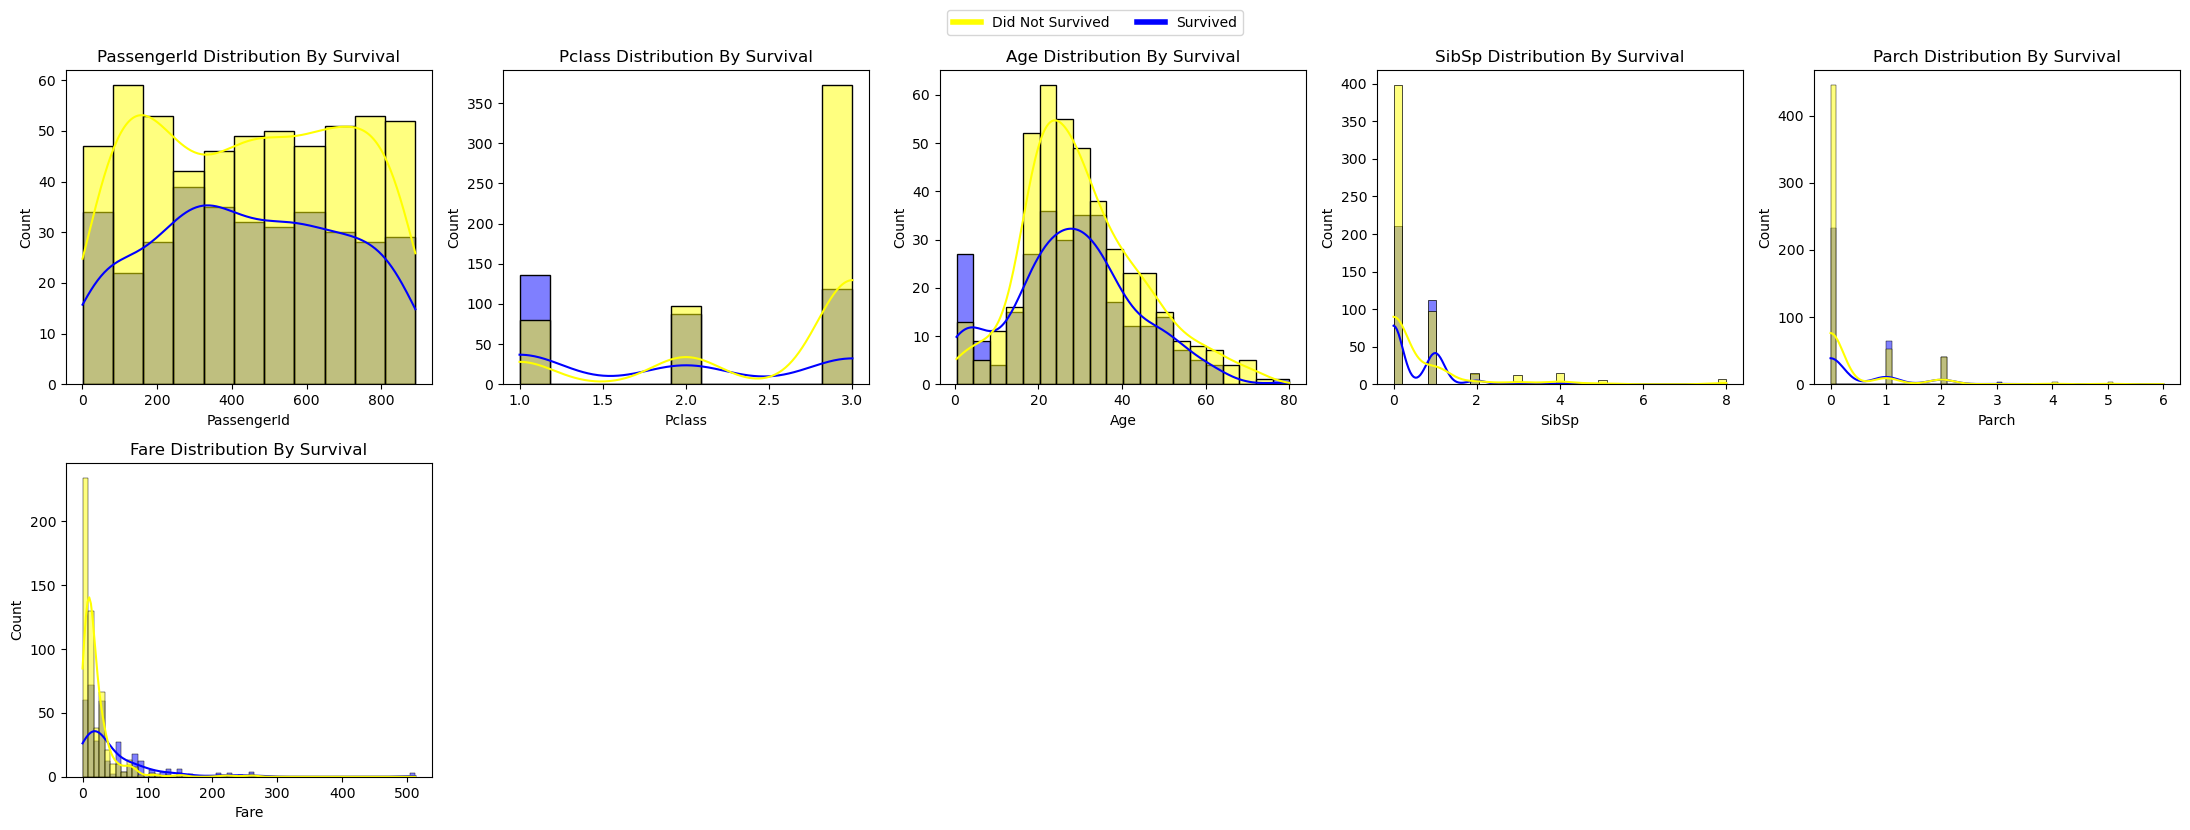

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue='Survived', kde=True, ax=ax,
                 palette=['yellow', 'blue'], legend=False)
    ax.set_title(f'{col} Distribution By Survival')

# to hide the unused graphs
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)
    
handles = [plt.Line2D([0], [0], color=c, lw=4) for c in ['yellow', 'blue']]
fig.legend(handles, ['Did Not Survived', 'Survived'], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.show()

### Numeric Feature Distributions

- **`PassengerId`** is spread fairly evenly across the dataset. Since it is just an identifier, it has no meaningful relationship with survival.
- **`Pclass`** contains three passenger classes. Most passengers were in 3rd class, which also had the lowest survival rate.
- **`Age`** Most passengers were between about 20 and 40 years old. **Younger children show a higher survival rate than some older groups.**
- **`SibSp`** and **`Parch`** most passengers had zero siblings/spouses or parents/children with them. These features were later combined into `FamilySize` to better represent family structure.
- **`Fare`** Most passengers paid relatively low fares, while a small number paid much higher fares, creating a strong right-skew and some outliers.

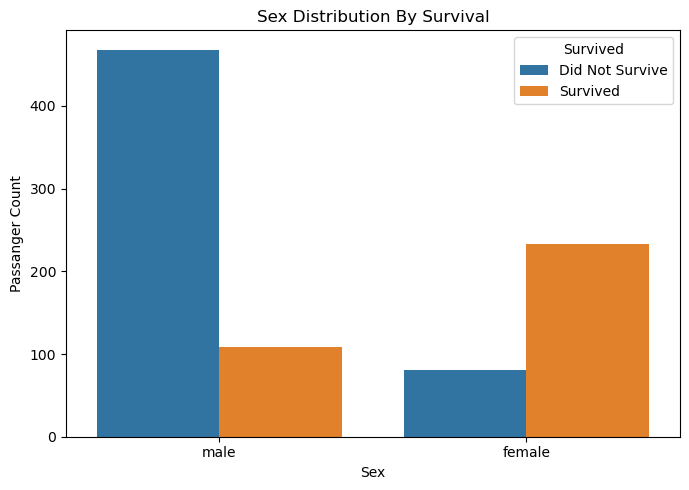

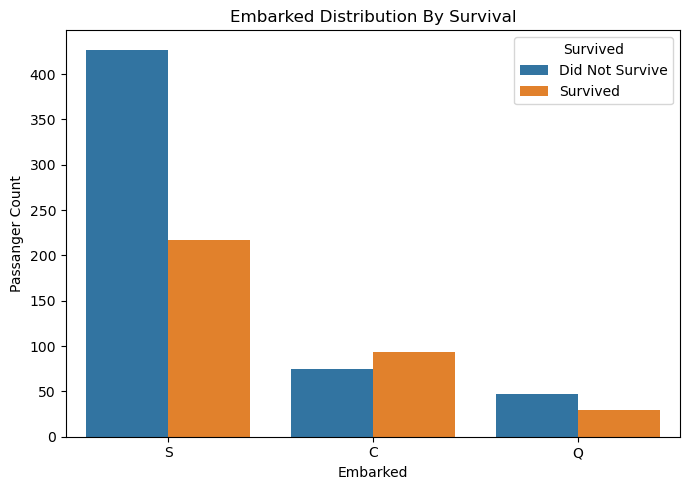

In [8]:
categorical_cols = [
    col for col in categorical_cols
    if df[col].nunique() < 10
]

for col in categorical_cols:
    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=df,
        x=col,
        hue='Survived'
    )

    plt.title(f'{col} Distribution By Survival')
    plt.xlabel(col)
    plt.ylabel('Passanger Count')
    plt.legend(title = 'Survived',  labels=['Did Not Survive', 'Survived'])

    plt.tight_layout()
    plt.show()

###  Categorical Feature Distributions

- **`Sex`** the  clearest survival signal in the whole dataset. the large majority
  of men did not survive (468 of 577), while the large majority of women did survive (233 of 314).
  This shows that women and children had the priorety for safty boats.
- **`Embarked`** — most passengers boarded at **S** ([Southampton](https://www.google.com/search?q=Southampton&rlz=1C1CHBD_arPS969PS969&oq=Southampton&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQLhiABDIHCAIQLhiABDIHCAMQABiABDIHCAQQABiABDIHCAUQABiABDIHCAYQABiABDIHCAcQABiABDIHCAgQLhiABDINCAkQLhivARjHARiABNIBBzc3NmowajeoAgCwAgA&sourceid=chrome&source=chrome.ob&ie=UTF-8) : ~644 passengers), a smaller group at
  **C** ([Cherbourg](https://www.google.com/search?q=cherbourg&rlz=1C1CHBD_arPS969PS969&oq=Cherbourg&gs_lcrp=EgZjaHJvbWUqCggAEAAY4wIYgAQyCggAEAAY4wIYgAQyBwgBEC4YgAQyBwgCEAAYgAQyDAgDEAAYQxiABBiKBTIHCAQQABiABDIHCAUQABiABDIHCAYQABiABDIHCAcQLhiABDIHCAgQABiABDIMCAkQABhDGIAEGIoF0gEHODQ2ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8) : ~168), and the fewest at **Q** ([Queenstown](https://www.google.com/search?q=queenstown&rlz=1C1CHBD_arPS969PS969&oq=Queenstown&gs_lcrp=EgZjaHJvbWUqDwgAEAAYQxjjAhiABBiKBTIPCAAQABhDGOMCGIAEGIoFMgwIARAuGEMYgAQYigUyDAgCEC4YQxiABBiKBTIMCAMQABhDGIAEGIoFMgcIBBAAGIAEMgcIBRAAGIAEMg0IBhAuGK8BGMcBGIAEMgcIBxAAGIAEMgcICBAAGIAEMgcICRAuGIAE0gEHNzk4ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8) : ~77).
   Survival rates varied across the three ports: **Southampton had considerably more non-survivors than survivors**, while **Cherbourg was the only port where survivors  outnumbered non-survivors**.
  > However, this relationship is likely indirect, as the port of embarkation may be associated with other factors such as passenger class and fare, rather than directly influencing survival.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Phase 2 : Feature engineering

### 2.1 Fixing missing values

The `Age` and `Embarked` features contain missing values. But we are not going to fill these missing values during the feature-engineering stage, we will leave them unchanged and allow the [preprocessing](#prep) stage of our machine learning pipeline to handle them. This ensures that the imputation process is learned only from the training data within each cross-validation fold, **to prevent data leakage** and keeping the entire workflow consistent.

<a id="eng"></a>
### 2.2 Feature Creation



#### 1.  `Deck` Feature : 
Deck Letters: These letters correspond to the actual horizontal decks of the ship, usually labeled A through G or T .
> <div style="text-align: center;"> <img src="tsos_a_2603417_f0003_oc.jpg" alt="how decks look " width="400" > </div>
Knowing a passenger's deck indicates how close they were to the lifeboats, which helps in  analyzing how a passenger's ship level affected survival

#### 2.  Family Size and Dynamics
The raw dataset provides two separate columns for family: SibSp (siblings and spouses) and Parch (parents and children). Combining them reveals the total family size, which heavily influenced boarding and evacuation priorities.
- `Family Size`: Created by adding SibSp + Parch + 1 (for the passenger themselves).
- `Is Alone`: A binary feature (0 or 1) that checks if Family Size equals 1. Traveling alone significantly lowered survival chances, especially for men.
- `Family Group`: Grouping family sizes into categories like Single, Small Family (2–4 members), and Large Family (5+ members). Small families had the highest survival rates because they could stick together and find lifeboats easily, while large families struggled to stay together.**(canceld)**
- `Surname`: To identify if certain individuals belong to the same family
  **(cancelled because there are so many unique surnames)**
  ```python
   df['Surname'] = df['Name'].str.split(',').str[0]

#### 3. Titles and social status
- `Title`: can give us information abot the person's status, it can tell if that person is engaged like Mr, Mrs or tell the job disription like  Dr(Christian minister or priest)



In [9]:
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")


df["Title"] = df["Name"].str.extract(         
    r",\s*([^.]*)\."
)

# Family Size and Dynamics
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


## 2.3 New Features's distribution

### 1. Numerical engineered data

<Axes: xlabel='FamilySize', ylabel='count'>

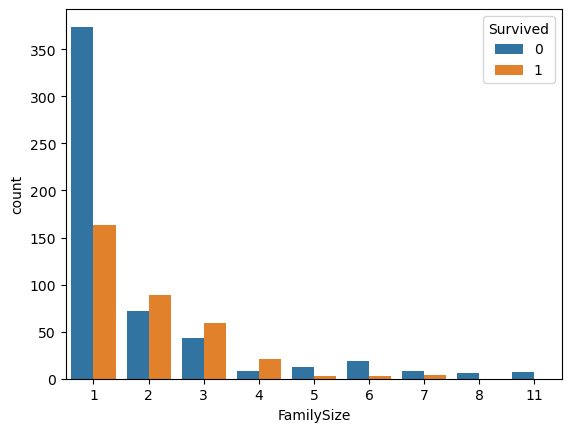

In [10]:
sns.countplot(data=df, x="FamilySize", hue="Survived")

### Observations :
- `FamilySize = 1` — The largest group. Passengers traveling alone had a lower survival rate.
- `FamilySize = 2–4` — These passengers had the highest survival rates, with survivors even outnumbering non-survivors at FamilySize = 4.
- `FamilySize ≥ 5` — Both the number of passengers and their survival rates dropped noticeably. Large families may have had more difficulty staying together during evacuation.

### 2. Categorical engineered features

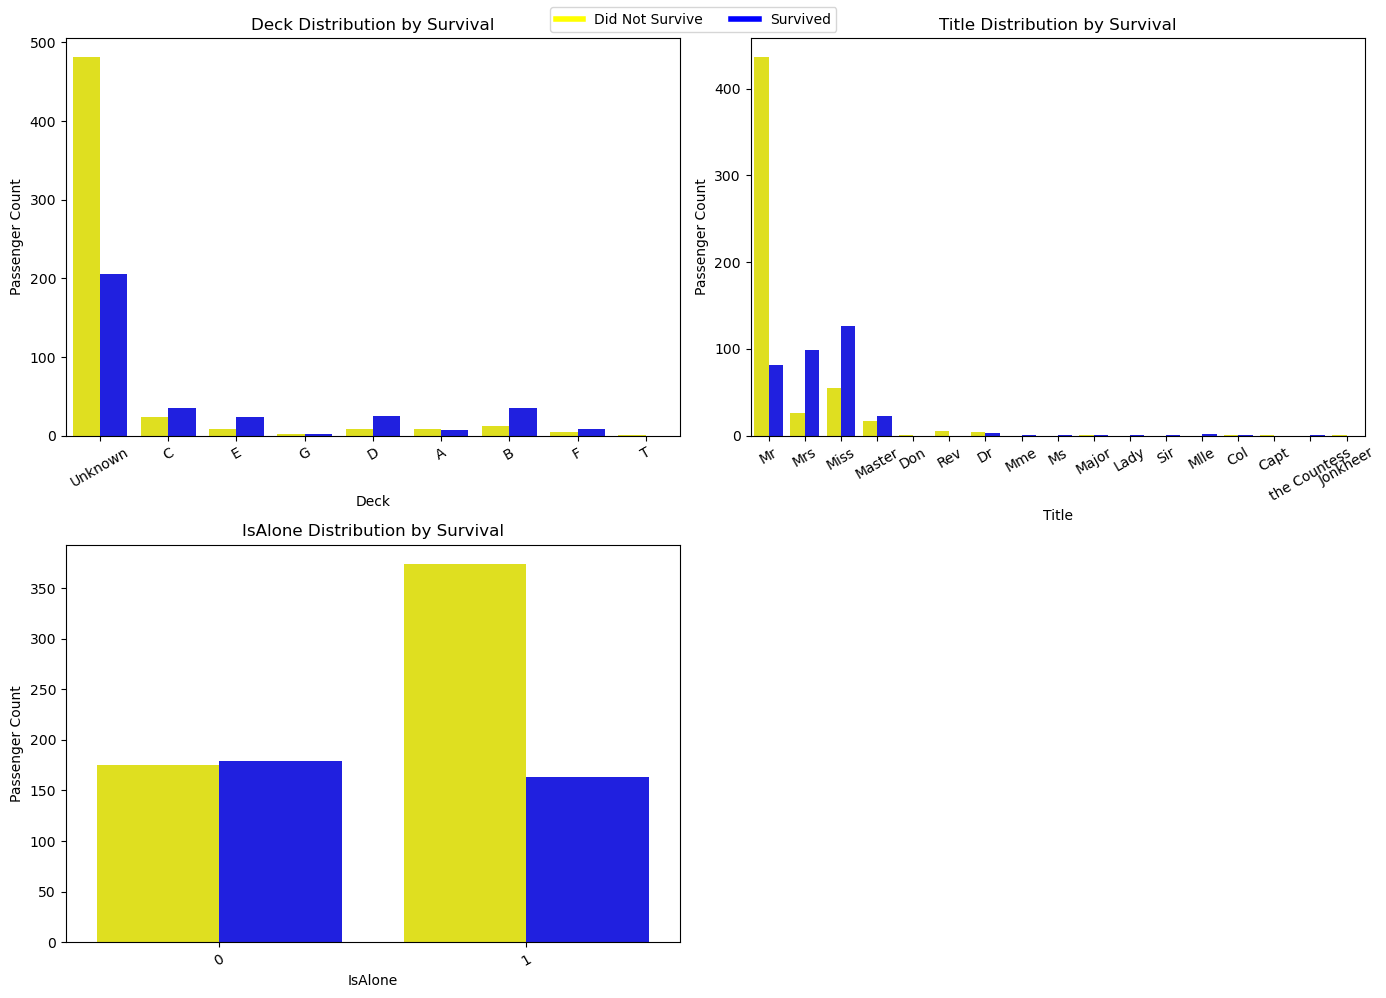

In [11]:

engineered_categorical = [
    'Deck',
    'Title',
    'IsAlone'
]

n_cols = 2
n_rows = (len(engineered_categorical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows,n_cols,figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, engineered_categorical):
    sns.countplot(
        data=df,
        x=col,
        hue='Survived',
        ax=ax,
        palette=['yellow', 'blue'],
        legend=False
    )

    ax.set_title(f'{col} Distribution by Survival')
    ax.set_xlabel(col)
    ax.set_ylabel('Passenger Count')
    ax.tick_params(axis='x', rotation=30)

# Hide unused axes
for ax in axes[len(engineered_categorical):]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], color='yellow', lw=4),plt.Line2D([0], [0], color='blue', lw=4)]

fig.legend(handles, ['Did Not Survive', 'Survived'],loc='upper center',ncol=2)

plt.tight_layout()
plt.show()

### Observations :

- `Deck` — Most passengers have an Unknown deck because many Cabin values were missing. Among the known decks, several had more survivors than non-survivors, which **may be related to higher passenger classes**.
- `Title` — **Mr had the lowest survival rate**, while Mrs, Miss, and Master had higher survival rates. This highlights the strong relationship between gender, age, and survival. Rare titles had very few passengers, so they are less reliable for individual analysis.
- `IsAlone` — **Passengers traveling with others had a much higher survival rate than those traveling alone**. This reinforces the pattern observed with FamilySize, showing that traveling alone was associated with lower survival.

## 2.3 Drop unnecessary raw columns

In [12]:
df = df.drop(
    columns=["PassengerId", "Ticket", "Cabin", "Name"]
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    object 
 8   Deck        891 non-null    object 
 9   Title       891 non-null    object 
 10  FamilySize  891 non-null    int64  
 11  IsAlone     891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Phase 3 : Data Splitting

The dataset was split into **80% training data** and **20% test data**. 
- The training set is used for preprocessing, cross-validation, and hyperparameter tuning
- The test set is kept completely unseen until the final evaluation.
>**NOTE :** The dataset and the engineered features are  reloaded and defined in this section to ensure that all required variables are available for smoother code execution.

In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")

df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df = df.drop(
    columns=["PassengerId", "Ticket", "Cabin", "Name"]
)

In [6]:

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived"])  
y = df["Survived"]  

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print(X_train.columns.tolist())


['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'Title', 'FamilySize', 'IsAlone']


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">


# Phase 4 : Building  Column Transformer And Handling Data


> The preprocessing stage prepares the selected features for the machine learning model. Since the Titanic dataset contains both numerical and categorical features, a `ColumnTransformer` is used to apply appropriate transformations to each type. Missing values in numerical and categorical columns are handled using imputation, numerical features are scaled, and categorical features are encoded into numerical representations using one-hot encoding. These preprocessing steps are included inside the pipeline so that they are fitted only on the training data, helping prevent data leakage during cross-validation and testing.

## 4.1  Seperating numeric data from catagorical ones 


In [9]:
# Numerical features
numeric_cols = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize',
    'IsAlone'
]

# Categorical features
categorical_cols = [
    'Pclass',
    'Sex',
    'Embarked',
    'Deck',
    'Title'
]

<a id="prep"></a>
## 4.2 Handling missing data, scalingm and encoding

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', numeric_preprocessor, numeric_cols),
    ('cat', categorical_preprocessor, categorical_cols)
])

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Phase 5 : Fitting the Model And Data Into Pipeline

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipe.fit(X_train, y_train)
pipe.predict(X_test)

y_pred = pipe.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 79.89%


### Computing a classification report and a confusion matrix for the results before tuning the model
> The Interpretations will be at the end of the notebook

Baseline Test Accuracy: 79.89%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.85      0.84       110
       Survived       0.75      0.71      0.73        69

       accuracy                           0.80       179
      macro avg       0.79      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



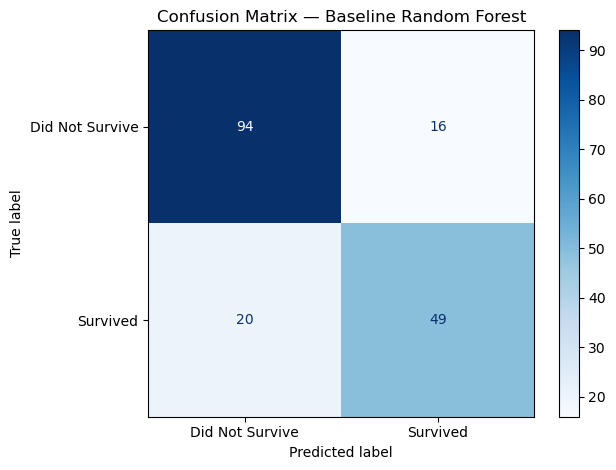

In [47]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions from the baseline (untuned) pipeline
y_pred_baseline = pipe.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Test Accuracy: {accuracy:.2%}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Did Not Survive", "Survived"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline Random Forest")
plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Phase 6 : Model Tuning

<a id="eval"></a>
### Using Grid Search and Stratified Cross-Validation:
To optimize the Random Forest model, we used GridSearchCV with 5-fold Stratified Cross-Validation.

> - Grid Search systematically tested different combinations of Random Forest hyperparameters, including `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`, to identify the combination that produced the best cross-validation performance.
>   
> - `StratifiedKFold` : **Since the target classes are slightly imbalanced**, with approximately **60%** of passengers not surviving and **40%** surviving, we used it  instead of standard K-Fold cross-validation. Stratification preserves a similar class distribution in each fold, ensuring that both classes are fairly represented during validation and providing a more reliable evaluation of the model.

In [43]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## 6.2 findinf best paraneters and cross validation score

In [44]:
results = pd.DataFrame(grid.cv_results_)

results[
    [
        'mean_test_score',
        'std_test_score',
        'param_model__n_estimators',
        'param_model__max_depth',
        'param_model__min_samples_split',
        'param_model__min_samples_leaf'
    ]
].sort_values(
    'mean_test_score',
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf
30,0.828701,0.026543,100,5,5,1
34,0.828691,0.028053,200,5,10,1
52,0.828691,0.025877,200,5,10,4
42,0.828691,0.028053,100,5,10,2
33,0.828691,0.028053,100,5,10,1
13,0.828661,0.021523,200,None,5,2
94,0.828661,0.018011,200,15,5,2
86,0.828652,0.020123,300,15,5,1
44,0.827292,0.027668,300,5,10,2
29,0.827292,0.027668,300,5,2,1


### Observations:

1. Best Hyperparameters:
`GridSearchCV` identified `100 estimators`, a `maximum tree depth of 5`, a `minimum of 5 samples required to split a node`, and a `minimum of 1 sample per leaf as the best-performing configuration`. This combination achieved a mean cross-validation accuracy of **82.87%**, with a standard deviation of approximately **2.65%** across the five stratified folds.

2. The results show that several  configurations achieved almost identical scores.This suggests **that the model's performance is relatively stable around these parameter settings rather than being dependent on one very specific combination.**

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Pdase 7 : Final test evaluation

In [45]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = grid.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did Not Survive", "Survived"]
))

Test Accuracy: 81.01%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



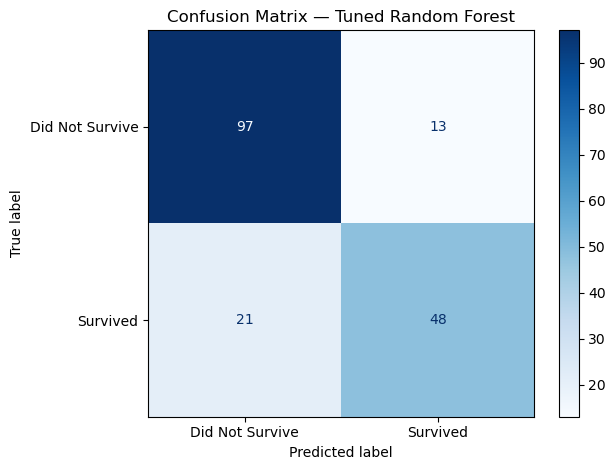

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from the best tuned pipeline
y_pred = grid.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()

| Metric                      | Before Tuning | After Tuning |   Change |
| --------------------------- | ------------: | -----------: | -------: |
| **Test Accuracy**           |        79.89% |   **81.01%** | +1.12 pp |
| Did Not Survive — Precision |           82% |          82% |        — |
| Did Not Survive — Recall    |           85% |      **88%** |    +3 pp |
| Did Not Survive — F1        |           84% |      **85%** |    +1 pp |
| Survived — Precision        |           75% |      **79%** |    +4 pp |
| Survived — Recall           |       **71%** |          70% |    −1 pp |
| Survived — F1               |           73% |      **74%** |    +1 pp |
| Macro F1                    |           79% |          79% |        — |


### Observations:
- **Overall accuracy improved from 79.89% to 81.01%**, showing that hyperparameter tuning provided a slight improvement in generalization.
- **The model became better at identifying passengers who did not survive**, with **recall** increasing from **85% to 88%.**
- **Survived class precision :** increased from 75% to 79%, meaning that when the tuned model predicted that a passenger survived, it was more often correct.
- **survivor recall slightly decreased** from **71%** to **70%**. Therefore, tuning did not improve the model's ability to find every actual survivor.
-  **F1-score for Survived still increased** from **73%** to **74%**, because the improvement in precision slightly outweighed the small decrease in recall.
-  **macro F1 remained at 79%**, suggesting that the overall balance of performance between the two classes changed very little.